<a href="https://colab.research.google.com/github/AdityaJare/ML-PRojects/blob/main/loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loan Appproval Prediction**

# Load Library


In [205]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Load Datasets

In [206]:
train_df = pd.read_csv('/content/loan-train (1).csv')
test_df = pd.read_csv('/content/loan-test (1).csv')

In [207]:
train_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [208]:
test_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


# Data Preprocessing

In [209]:
print(train_df.shape)
print(test_df.shape)

(614, 13)
(367, 12)


In [210]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [211]:
train_df.isnull().sum()


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [212]:
test_df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [213]:
train_df.duplicated().sum()

np.int64(0)

In [214]:
test_df.duplicated().sum()

np.int64(0)

In [215]:
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [216]:
test_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [217]:
for col in ['Gender','Married','Dependents','Self_Employed','Credit_History']:
        train_df[col].fillna(train_df[col].mode()[0], inplace=True)
        test_df[col].fillna(test_df[col].mode()[0], inplace=True)

/tmp/ipython-input-3644222039.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].mode()[0], inplace=True)
/tmp/ipython-input-3644222039.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [218]:
for col in ['LoanAmount','Loan_Amount_Term']:
        train_df[col].fillna(train_df[col].median(), inplace=True)
        test_df[col].fillna(test_df[col].median(), inplace=True)

/tmp/ipython-input-2575846398.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(train_df[col].median(), inplace=True)
/tmp/ipython-input-2575846398.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [219]:
train_df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [220]:
test_df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


## EDA

In [221]:
train_df.select_dtypes(include= "number").columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

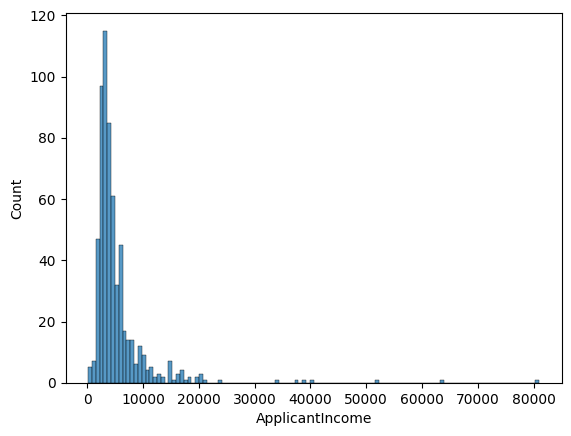

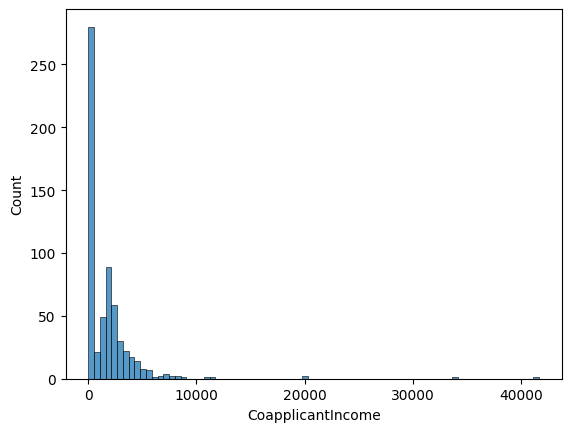

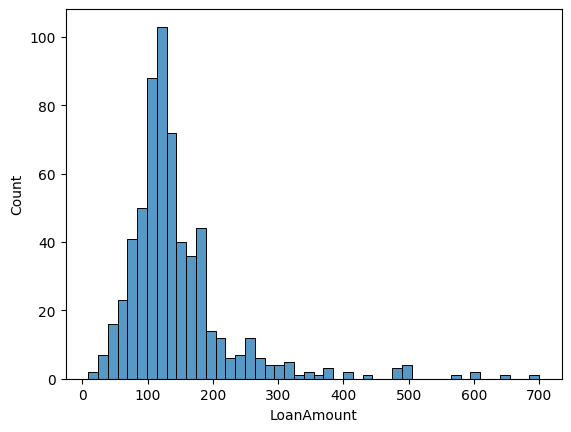

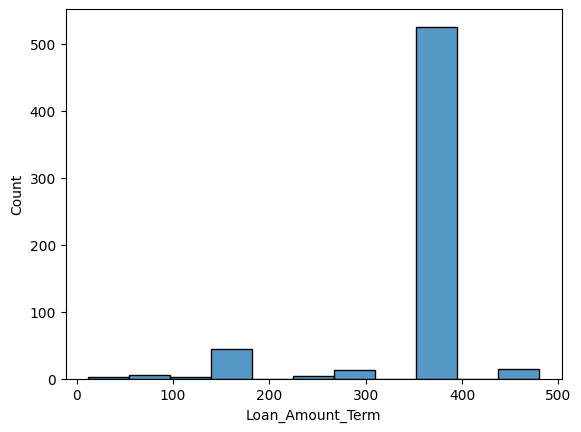

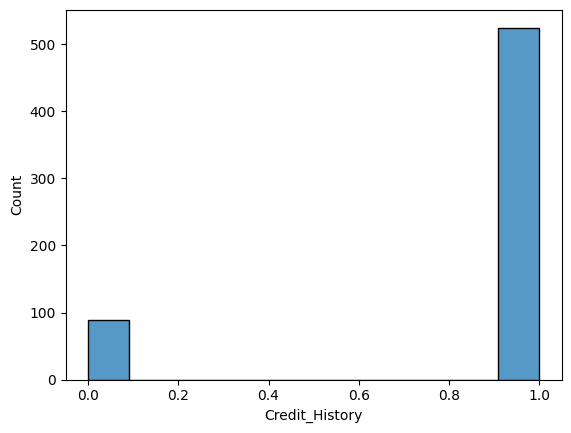

In [222]:
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History']:
       sns.histplot(data= train_df, x= col)
       plt.show()

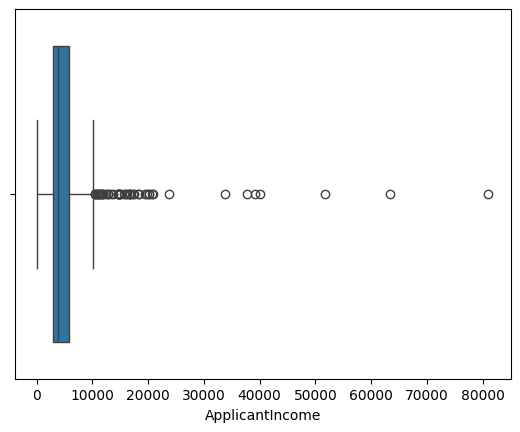

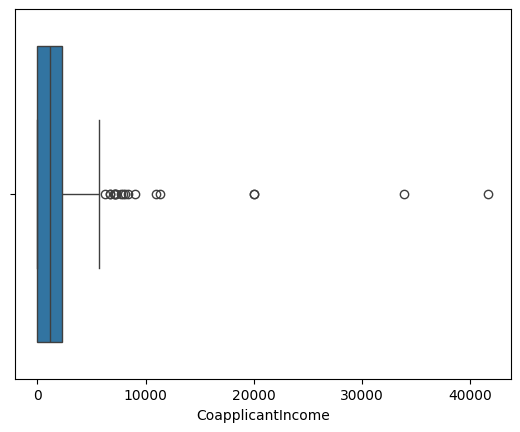

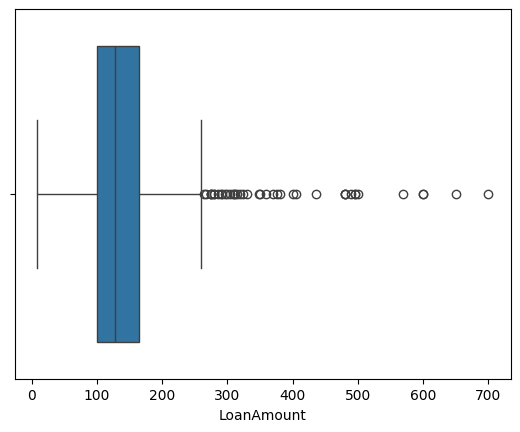

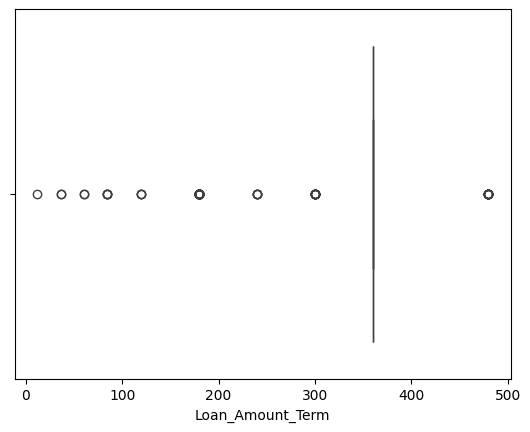

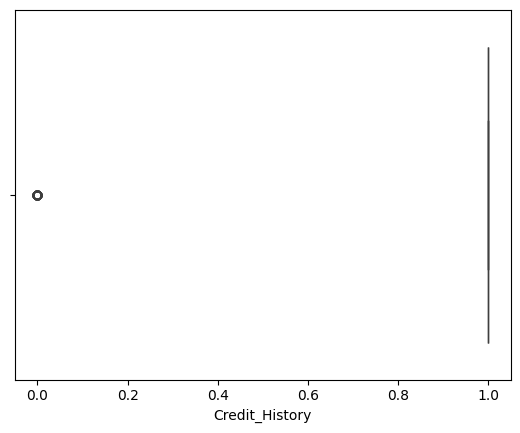

In [223]:
for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History']:
       sns.boxplot(data = train_df, x= col)
       plt.show()

<Axes: xlabel='Loan_Status', ylabel='ApplicantIncome'>

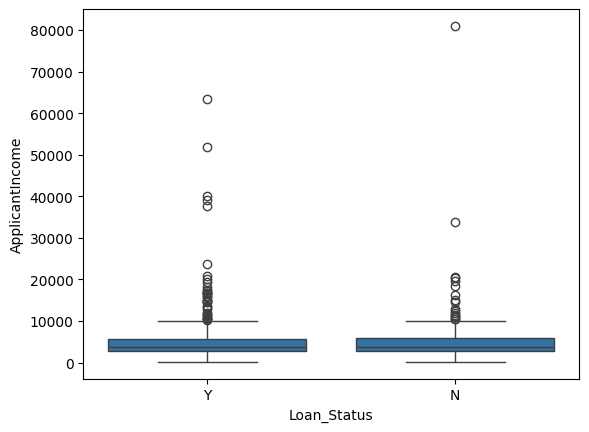

In [224]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=train_df)


## outlier treatment

In [225]:
train_df['ApplicantIncome_log'] = np.log1p(train_df['ApplicantIncome'])
train_df['CoapplicantIncome_log'] = np.log1p(train_df['CoapplicantIncome'])

test_df['ApplicantIncome_log'] = np.log1p(test_df['ApplicantIncome'])
test_df['CoapplicantIncome_log'] = np.log1p(test_df['CoapplicantIncome'])


In [226]:
def term_category(x):
    if x <= 180:
        return 'Short'
    elif x <= 300:
        return 'Medium'
    else:
        return 'Long'

train_df['Loan_Amount_Term_Cat'] = train_df['Loan_Amount_Term'].apply(term_category)
test_df['Loan_Amount_Term_Cat'] = test_df['Loan_Amount_Term'].apply(term_category)



In [227]:
upper_limit = train_df['LoanAmount'].quantile(0.99)
train_df['LoanAmount'] = np.where(train_df['LoanAmount'] > upper_limit, upper_limit, train_df['LoanAmount'])

upper_limit_test = train_df['LoanAmount'].quantile(0.99)   # use train cutoff!
test_df['LoanAmount'] = np.where(test_df['LoanAmount'] > upper_limit_test, upper_limit_test, test_df['LoanAmount'])

In [228]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Gender', 'Married', 'Dependents', 'Education',
            'Self_Employed', 'Property_Area', 'Loan_Amount_Term_Cat']

le = LabelEncoder()
for col in cat_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

In [229]:
x = train_df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = train_df['Loan_Status'].map({'Y': 1, 'N': 0})

## Train test split

In [230]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify =y)

# Model Training

## Logistic Regression

In [231]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [232]:
y_lr_pred = lr.predict(x_val)
print("Logistic Regression Results")
print("Validation Accuracy:", accuracy_score(y_val, y_lr_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_lr_pred))

Logistic Regression Results
Validation Accuracy: 0.8617886178861789

Confusion Matrix:
 [[22 16]
 [ 1 84]]


In [233]:
X_test = test_df.drop(['Loan_ID'], axis=1)
test_pred = lr.predict(X_test)

submission = pd.DataFrame({
    'Loan_ID': test_df['Loan_ID'],
    'Loan_Status': ['Y' if x==1 else 'N' for x in test_pred]
})

submission.to_csv("submission.csv", index=False)

## Random Forest

In [234]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,
                            random_state=42)
rf.fit(x_train, y_train)
y_rf_pred = rf.predict(x_val)

In [235]:
print("Random Forest Results")
print("Validation Accuracy:", accuracy_score(y_val, y_rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_rf_pred))

Random Forest Results
Validation Accuracy: 0.8455284552845529

Confusion Matrix:
 [[24 14]
 [ 5 80]]


In [236]:
X_test = test_df.drop(['Loan_ID'], axis=1)
test_pred = lr.predict(X_test)

submission = pd.DataFrame({
    'Loan_ID': test_df['Loan_ID'],
    'Loan_Status': ['Y' if x==1 else 'N' for x in test_pred]
})

submission.to_csv("submission1.csv", index=False)

## Gradient Boosting

In [237]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=1500,
    learning_rate=0.08,
    max_depth=3,
    random_state=42
)

gb.fit(x_train, y_train)
y_gb_pred = gb.predict(x_val)

In [238]:
print("🔹 Gradient Boosting Results")
print("Validation Accuracy:", accuracy_score(y_val, y_gb_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_gb_pred))


🔹 Gradient Boosting Results
Validation Accuracy: 0.7804878048780488

Confusion Matrix:
 [[25 13]
 [14 71]]


In [239]:
X_test = test_df.drop(['Loan_ID'], axis=1)
test_pred = gb.predict(X_test)

submission = pd.DataFrame({
    'Loan_ID': test_df['Loan_ID'],
    'Loan_Status': ['Y' if x==1 else 'N' for x in test_pred]
})

submission.to_csv("submission2.csv", index=False)